In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold


## Dataset summary

In [134]:
df = pd.read_csv('../data/processed/final_genomics_train_data.csv')

In [135]:
df.shape

(549, 15458)

In [136]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Columns: 15458 entries, Genotype to DON
dtypes: float64(14925), int64(532), str(1)
memory usage: 64.8 MB


## Missing Values

In [137]:
miss_count=df.isna().sum()
type(miss_count)

miss_count[miss_count>0]
np.where(miss_count>0)

(array([], dtype=int64),)

## Duplicated Values

In [138]:
duplicate = df.duplicated()
duplicate.sum()
df[duplicate]

,Genotype,S1A_687822,S1A_1195489,S1A_1234081,S1A_4781815,S1A_4929734,S1A_5190325,S1A_5548635,S1A_5548650,S1A_5857413,...,SUNKNOWN_336365,SUNKNOWN_336436,SUNKNOWN_336436.1,SUNKNOWN_339127,SUNKNOWN_343096,SUNKNOWN_349202,SUNKNOWN_349202.1,SUNKNOWN_349202.2,SUNKNOWN_349202.3,DON


## Target Distribution

In [139]:
y = df["DON"]
y.shape

(549,)

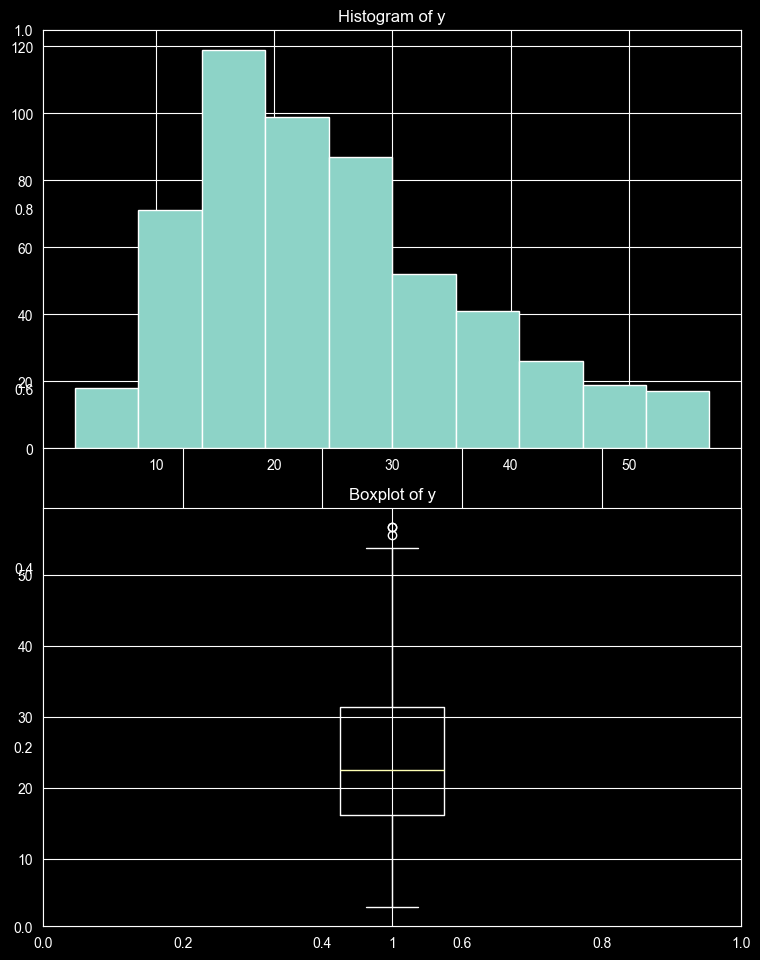

0.7115199321300033


In [164]:
plt.subplots(figsize=(8,10))
plt.subplot(2,1,1)
plt.hist(y,bins=10)
plt.title('Histogram of y')

plt.subplot(2,1,2)
plt.boxplot(y)
plt.title('Boxplot of y')

plt.tight_layout()
plt.show()
print(y.skew())

In [ ]:
#0.7115199321300033
#Right skewed most data are in the left but some big data are in right

## Outlier Detection

In [141]:
#Outliers
q1 = y.quantile(0.25)
q3 = y.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr


outliers = y[(y < lower_bound) | (y > upper_bound)]

outlier_count = len(outliers)
outlier_percentage = (outlier_count / len(y)) * 100

print(f'Outlier count: {outlier_count}')
print(f'Outlier percentage: {outlier_percentage:.2f}%')

Outlier count: 3
Outlier percentage: 0.55%


In [142]:
print(outliers)

60     56.826081
185    56.776081
208    55.576081
Name: DON, dtype: float64


## Zero Variance Features

In [143]:
# روش درست (بدون inplace):
genotypes = df["Genotype"]
y = df["DON"]

# حذف ستون‌ها و ریختن نتیجه در X
X = df.drop(columns=["Genotype", "DON"])


In [144]:
X

,S1A_687822,S1A_1195489,S1A_1234081,S1A_4781815,S1A_4929734,S1A_5190325,S1A_5548635,S1A_5548650,S1A_5857413,S1A_6110098,...,SUNKNOWN_323958,SUNKNOWN_336365,SUNKNOWN_336436,SUNKNOWN_336436.1,SUNKNOWN_339127,SUNKNOWN_343096,SUNKNOWN_349202,SUNKNOWN_349202.1,SUNKNOWN_349202.2,SUNKNOWN_349202.3
0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0
1,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1,1.0,1.0,1.0,1.0,0,1.0,1.0,1.0,1.0
2,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1,1.0,1.0,1.0,-1.0,1,1.0,1.0,1.0,1.0
3,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,...,1,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0
4,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,...,1,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,1,1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,...,1,1.0,1.0,1.0,-1.0,1,1.0,1.0,1.0,0.0
545,1,1.0,1.0,1.0,-1.0,1.0,1.0,0.0,1.0,1.0,...,1,0.0,1.0,0.0,1.0,-1,0.0,1.0,-1.0,1.0
546,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0
547,1,-1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1,1.0,1.0,-1.0,1.0,1,1.0,1.0,1.0,1.0


In [145]:
np.where(X.columns[X.std()==0])
trash_features = X.columns[X.std() == 0]
X_cleaned = X.drop(columns=trash_features)

In [146]:
X_cleaned.shape

(549, 15456)

In [129]:
#from sklearn.feature_selection import VarianceThreshold
#selector = VarianceThreshold(threshold=0.0)

#X_cleaned  = selector.fit_transform(X)
#X_cleaned.shape

(549, 15456)

## VarianceThreshold

In [147]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# ۱. اعمال فیلتر واریانس
selector2 = VarianceThreshold(threshold=0.01)
X_array = selector2.fit_transform(X_cleaned)

# ۲. برگرداندن به فرمت DataFrame به همراه نام ستون‌های اصلی
X_cleaned = pd.DataFrame(
    X_array,
    index=X_cleaned.index,
    columns=X_cleaned.columns[selector2.get_support()]
)

# ۳. بررسی ابعاد جدید
print(X_cleaned.shape)

(549, 15448)


In [148]:
X_cleaned

,S1A_687822,S1A_1195489,S1A_1234081,S1A_4781815,S1A_4929734,S1A_5190325,S1A_5548635,S1A_5548650,S1A_5857413,S1A_6110098,...,SUNKNOWN_323958,SUNKNOWN_336365,SUNKNOWN_336436,SUNKNOWN_336436.1,SUNKNOWN_339127,SUNKNOWN_343096,SUNKNOWN_349202,SUNKNOWN_349202.1,SUNKNOWN_349202.2,SUNKNOWN_349202.3
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,1.0,1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,...,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,0.0
545,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,1.0,-1.0,0.0,1.0,-1.0,1.0
546,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
547,1.0,-1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Correlation Heatmap

<Axes: >

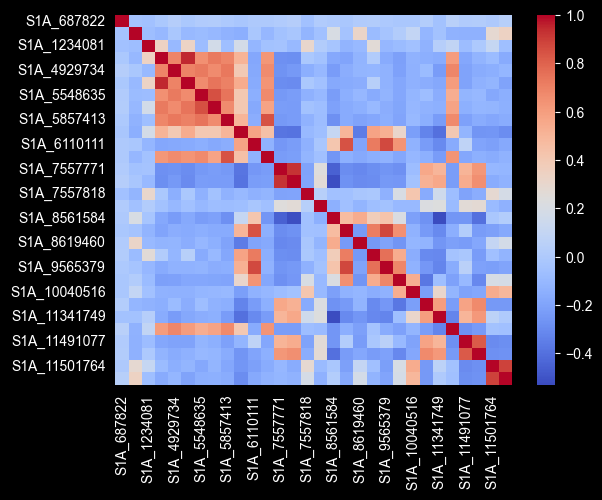

In [152]:
subset_f = X_cleaned.iloc[:,:30]
corr_matrix = subset_f.corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm",cbar=True)

<Axes: >

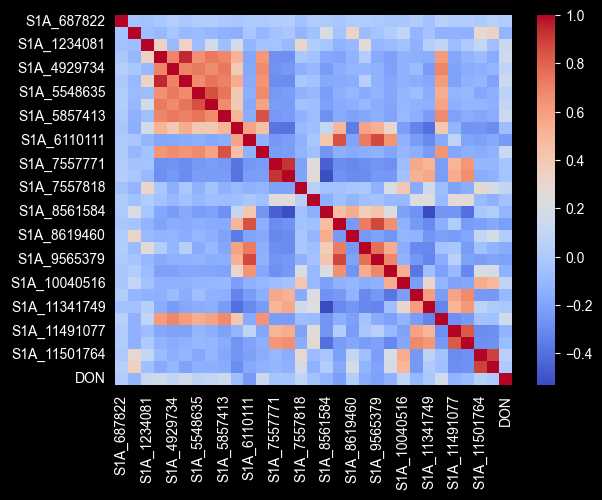

In [158]:
subset_f = X_cleaned.iloc[:, :30].copy()
subset_f['DON'] = y
corr_matrix2 = subset_f.corr()
sns.heatmap(corr_matrix2, annot=False, cmap="coolwarm",cbar=True)

## Distribution of SNP values

In [165]:
values = X.to_numpy().ravel()

In [166]:
total = len(values)

major = np.sum(values == 1)
minor = np.sum(values == -1)
hetero = np.sum(values == 0)

imputed = np.sum(
    (values != 1) &
    (values != -1) &
    (values != 0)
)

print(f"Major allele (1): {major} ({major/total*100:.2f}%)")
print(f"Minor allele (-1): {minor} ({minor/total*100:.2f}%)")
print(f"Heterozygous (0): {hetero} ({hetero/total*100:.2f}%)")
print(f"Imputed values: {imputed} ({imputed/total*100:.2f}%)")

Major allele (1): 6623496 (78.06%)
Minor allele (-1): 1536592 (18.11%)
Heterozygous (0): 322128 (3.80%)
Imputed values: 3128 (0.04%)


The SNP matrix is predominantly composed of homozygous major and minor alleles. Heterozygous genotypes are rare, which is expected because the dataset consists of advanced inbred wheat lines. Approximately 4% of genotype values correspond to imputed missing data.

